#### Modelo de regresión logística

Entrenamos el modelo con validación cruzada dentro del train. Evaluamos con ROC-AUC (no accuracy, por el desbalance)

In [8]:
#impprtación de librerías
from pathlib import Path
import sys
import numpy as np

In [9]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_split import load_raw_data, split_data

df = load_raw_data()
X_train, X_test, y_train, y_test = split_data(df)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (120000, 10) | Test: (30000, 10)


In [10]:
from src.models.train_model import buil_logistic_pipeline
pipe = buil_logistic_pipeline()
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fix_errors', ...), ('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fix...001D197C61440>
,"fe

In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv =  StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("-----ROC-AUC por fold:",np.round(scores,4))
print("-----ROC-AUC media:",round(scores.mean(),4), "+/-", round(scores.std(),4))

-----ROC-AUC por fold: [0.8188 0.8128 0.8088 0.8093 0.8167]
-----ROC-AUC media: 0.8133 +/- 0.004


In [13]:
#entrenamiento del pipeline, sobre todo el train y análisis de los coeficientes
from src.models.evaluation import risk_metrics, coefficient_importance
pipe.fit(X_train, y_train)
imp = coefficient_importance(pipe, X_train.columns)
imp

,variable,coeficiente,odds_ratio
0,NumberOfTimes90DaysLate,0.614400,1.848547
1,NumberOfTime30-59DaysPastDueNotWorse,0.507600,1.661300
2,age,-0.444788,0.640960
3,NumberOfTime60-89DaysPastDueNotWorse,0.368043,1.444904
4,MonthlyIncome,-0.268984,0.764155
5,DebtRatio,-0.126854,0.880862
6,NumberRealEstateLoansOrLines,0.117632,1.124830
7,NumberOfDependents,0.037794,1.038517
8,NumberOfOpenCreditLinesAndLoans,0.006299,1.006319
9,RevolvingUtilizationOfUnsecuredLines,-0.001744,0.998257


In [ ]:
#métricas del riesgo sobre el test
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("--------Métricas de riesgo sobre el test:")
print(risk_metrics(y_test, y_proba))

--------Métricas de riesgo sobre el test:
{'ROC_AUC': 0.8205, 'Gini': 0.6409, 'KS': np.float64(0.499)}


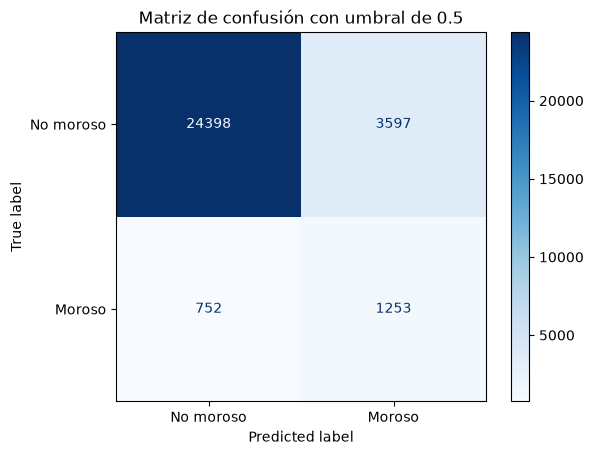

In [21]:
#matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No moroso","Moroso"]).plot(cmap="Blues")
plt.title("Matriz de confusión con umbral de 0.5")
plt.show()